# Young-Adult Interstate Migration: Policy Incentives, Social Networks, and Capacity Feedback — V8
## A spatial agent-based model with migration chains, housing/job constraints, and robustness tests

**Core question**

> How strong must a geographically targeted housing-and-employment policy be to overcome young adults' social attachment, and when do migration chains and local capacity constraints amplify or offset that response?

This revision adds two forms of robustness requested in the model review: **social-threshold sensitivity** and **network-homophily sensitivity**. It also adds a lagged **rent response to excess housing demand** so housing pressure affects next-year migration utility rather than appearing only as a hard capacity rejection.

The former `happiness` measure is renamed **social utility index**. It is a transparent model-internal composite score, not a validated subjective-well-being survey measure. Its role is diagnostic rather than a real-world welfare ranking.

**V7 review-closure revision.** This version closes the remaining high-priority review comments: mover-level unit consistency, a soft housing-capacity mechanism with lagged rent feedback, a main-horizon ACS move-rate calibration, a wider policy-intensity sweep, an external-competition scope audit using ACS PUMS, a Tulsa Remote monetary-reference diagnostic, and an explicit BRFSS coverage audit. Optional full geography expansion to Oklahoma/West Virginia is deliberately not mixed into the main eight-state model because it would require a new state-space and IRS-route recalibration; it is documented as external-validation future work rather than presented as completed evidence.


### Reproducible results build

This executed copy displays the **fully simulated V7 results** from the accompanying `abm_outputs_research_plan_v7/` cache. The source notebook keeps the complete simulation code; this results build loads the saved seed-level outputs so figures and tables can be reproduced quickly without rerunning hundreds of ABM realizations. The cache was generated by the same V7 model before this notebook was rendered.

In [ ]:
import json
import math
import os
import warnings
import zipfile
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import t as student_t

try:
    from joblib import Parallel, delayed
    JOBLIB_AVAILABLE = True
except Exception:
    JOBLIB_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 170)

RANDOM_SEED = 42
BASE_YEAR = 2026

STATE_CODES = ["CA", "TX", "NY", "FL", "MA", "NC", "IL", "WA"]
STATE_NAMES = {
    "CA": "California", "TX": "Texas", "NY": "New York", "FL": "Florida",
    "MA": "Massachusetts", "NC": "North Carolina", "IL": "Illinois", "WA": "Washington",
}

# Full research design. Reduce these values only for debugging.
BASELINE_AGENTS = 1000
BASELINE_YEARS = 20
BASELINE_SEEDS = list(range(101, 109))

EXPERIMENT_AGENTS = 600
EXPERIMENT_YEARS = 12
CROSS_SEEDS = list(range(201, 209))
SWEEP_SEEDS = list(range(301, 309))
SHOCK_SEEDS = list(range(401, 407))
SENSITIVITY_SEEDS = list(range(501, 505))
CALIBRATION_SEEDS = (901, 902, 903, 904, 905)

N_JOBS = 1  # deterministic final execution; avoids process-backend stalls in notebook kernels
N_AGENTS = BASELINE_AGENTS
N_YEARS = BASELINE_YEARS

POLICY_COLS = [
    "housing_policy",
    "employment_incentive",
    "migration_incentive",
]

SOCIAL_UTILITY_WEIGHTS = {
    "peer": 0.30,
    "coorigin": 0.20,
    "home": 0.10,
    "employment": 0.20,
    "income": 0.10,
    "affordability": 0.10,
}

INTERACTION_COLORS = {
    "weak": "#4C72B0",
    "medium": "#DD8452",
    "strong": "#55A868",
}



def mean_t_ci(series):
    x = np.asarray(pd.Series(series).dropna(), dtype=float)
    if len(x) == 0:
        return np.nan, np.nan
    mean = float(x.mean())
    if len(x) == 1:
        return mean, np.nan
    half = float(
        student_t.ppf(0.975, len(x) - 1)
        * x.std(ddof=1)
        / np.sqrt(len(x))
    )
    return mean, half


def run_cases(func, cases, n_jobs=N_JOBS):
    """Use joblib when possible; fall back to deterministic serial execution."""
    if JOBLIB_AVAILABLE and n_jobs > 1:
        try:
            return Parallel(n_jobs=n_jobs, backend="loky")(
                delayed(func)(*case) for case in cases
            )
        except Exception as exc:
            print("Parallel execution unavailable; using serial fallback:", type(exc).__name__)
    return [func(*case) for case in cases]

print("Environment ready.")

Environment ready.


## 1. Empirical state inputs

In [ ]:
def build_real_state_snapshot():
    raw = pd.DataFrame({
        "state": STATE_CODES,

        "young_adult_population_est_18_35": [
            9_793_452, 7_754_857, 4_729_200, 4_917_820,
            1_747_318, 2_609_754, 2_985_755, 1_951_781
        ],

        "median_household_income": [
            95_521, 75_780, 82_095, 73_311,
            99_858, 70_804, 80_306, 94_605
        ],

        "median_gross_rent_monthly": [
            1_992, 1_413, 1_561, 1_719,
            1_757, 1_245, 1_238, 1_731
        ],

        "civilian_labor_force": [
            20_137_422, 15_612_815, 10_107_326, 11_191_144,
            3_908_554, 5_449_906, 6_642_661, 4_069_534
        ],
        "employed": [
            19_026_566, 14_926_761, 9_600_693, 10_731_195,
            3_754_447, 5_230_146, 6_329_130, 3_887_150
        ],

        "bachelor_plus_share_25plus": [
            0.3748778859, 0.3424161436, 0.4063985602, 0.3491620625,
            0.4778163562, 0.3679334714, 0.3827775836, 0.4045106716
        ],

        "housing_units": [
            14_762_527, 12_394_809, 8_631_232, 10_451_823,
            3_045_867, 4_979_177, 5_470_727, 3_361_561
        ],
        "vacant_housing_units": [
            1_062_711, 1_134_164, 821_965, 1_485_421,
            244_883, 586_508, 399_439, 260_296
        ],

        "ipeds_12mo_enrollment": [
            3_464_000, 2_083_195, 1_423_248, 1_421_104,
            587_505, 689_935, 970_675, 423_112
        ],

        "annual_infant_childcare_price": [
            19_547, 11_024, 19_584, 12_639,
            24_005, 12_251, 16_373, 20_370
        ],

        "public_4yr_instate_tuition": [
            10_641, 11_187, 8_579, 6_364,
            14_839, 7_437, 15_362, 11_506
        ],
    }).set_index("state")

    raw["employment_rate_labor_force"] = (
        raw["employed"] / raw["civilian_labor_force"]
    )
    raw["vacancy_rate"] = (
        raw["vacant_housing_units"] / raw["housing_units"]
    )
    raw["ipeds_enrollment_per_young_adult"] = (
        raw["ipeds_12mo_enrollment"]
        / raw["young_adult_population_est_18_35"]
    )
    return raw

real_raw_data = build_real_state_snapshot()

In [ ]:
def mean_index(series):
    x = series.astype(float)
    return x / x.mean()

def prepare_state_data(raw):
    df = raw.copy()

    df["youth_pop_weight"] = mean_index(
        df["young_adult_population_est_18_35"]
    )
    df["wage_index"] = mean_index(df["median_household_income"])
    df["rent_index"] = mean_index(df["median_gross_rent_monthly"])
    df["job_index"] = mean_index(df["employment_rate_labor_force"])
    df["education_access_index"] = mean_index(
        df["ipeds_enrollment_per_young_adult"]
    )
    df["tuition_index"] = mean_index(df["public_4yr_instate_tuition"])
    df["childcare_cost_index"] = mean_index(
        df["annual_infant_childcare_price"]
    )
    df["housing_capacity_index"] = mean_index(df["vacancy_rate"])
    df["college_share_proxy"] = df["bachelor_plus_share_25plus"]

    return df

state_data = prepare_state_data(real_raw_data)

## 2. Spatial environment and IRS route calibration

In [ ]:
STATE_COORDS = {
    "CA": (36.8, -119.4),
    "TX": (31.0, -99.9),
    "NY": (42.9, -75.5),
    "FL": (27.8, -81.7),
    "MA": (42.3, -71.8),
    "NC": (35.5, -79.4),
    "IL": (40.0, -89.2),
    "WA": (47.4, -120.7),
}

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = (
        np.sin(dp / 2) ** 2
        + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    )
    return 2 * R * np.arcsin(np.sqrt(a))

distance_km = pd.DataFrame(
    index=STATE_CODES, columns=STATE_CODES, dtype=float
)

for s1 in STATE_CODES:
    for s2 in STATE_CODES:
        distance_km.loc[s1, s2] = haversine_km(
            *STATE_COORDS[s1], *STATE_COORDS[s2]
        )

distance_index = distance_km / distance_km.to_numpy().max()

In [ ]:
IRS_ROUTES = [
    ("CA","TX",44417), ("TX","CA",24970),
    ("CA","NY",20595), ("NY","CA",18440),
    ("CA","FL",20241), ("FL","CA",14113),
    ("CA","MA",6565),  ("MA","CA",7767),
    ("CA","NC",9978),  ("NC","CA",6470),
    ("CA","IL",9063),  ("IL","CA",10407),
    ("CA","WA",24625), ("WA","CA",17871),

    ("TX","NY",9433),  ("NY","TX",12961),
    ("TX","FL",20050), ("FL","TX",24196),
    ("TX","MA",3394),  ("MA","TX",4218),
    ("TX","NC",8694),  ("NC","TX",8387),
    ("TX","IL",8236),  ("IL","TX",12078),
    ("TX","WA",9307),  ("WA","TX",9863),

    ("NY","FL",43187), ("FL","NY",22011),
    ("NY","MA",10479), ("MA","NY",11027),
    ("NY","NC",13811), ("NC","NY",6906),
    ("NY","IL",4436),  ("IL","NY",5325),
    ("NY","WA",3649),  ("WA","NY",3513),

    ("FL","MA",8058),  ("MA","FL",12159),
    ("FL","NC",20553), ("NC","FL",14530),
    ("FL","IL",9299),  ("IL","FL",14834),
    ("FL","WA",5333),  ("WA","FL",5661),

    ("MA","NC",3483),  ("NC","MA",2213),
    ("NC","WA",2371),  ("WA","NC",2464),
    ("IL","WA",2734),  ("WA","IL",2158),
]

irs_flows = pd.DataFrame(
    IRS_ROUTES,
    columns=["origin", "destination", "returns"]
)
irs_flows["observed_share"] = (
    irs_flows["returns"]
    / irs_flows.groupby("origin")["returns"].transform("sum")
)

irs_flow_matrix = (
    irs_flows.pivot(
        index="origin", columns="destination", values="returns"
    )
    .reindex(index=STATE_CODES, columns=STATE_CODES)
)

for s in STATE_CODES:
    irs_flow_matrix.loc[s, s] = np.nan

In [ ]:
STATE_POS = {s: i for i, s in enumerate(STATE_CODES)}

PRIOR_BETA = np.array([
    1.10,  # income
    1.25,  # jobs
    1.00,  # rent
    0.20,  # distance
    0.45,  # education
    0.50,  # childcare
], dtype=float)

PRIOR_SCALE = np.array([1.0, 1.0, 1.0, 0.5, 0.5, 0.5])
CALIBRATION_TEMPERATURE = 0.85

def calibration_features():
    return {
        "log_income": np.log(
            state_data["wage_index"].to_numpy()
        ),
        "jobs": state_data["job_index"].to_numpy(),
        "rent": state_data["rent_index"].to_numpy(),
        "education": state_data[
            "education_access_index"
        ].to_numpy(),
        "childcare": (
            1.0
            / state_data["childcare_cost_index"]
        ).to_numpy(),
    }

CAL_FEATURES = calibration_features()

def predicted_route_shares(theta, origins):
    """
    Deterministic expected route shares.

    Rather than representing each origin with one average person,
    the calibration mixes four composition groups:
      college / non-college × child / no-child.

    This better matches the heterogeneous utility function used in
    the ABM while keeping calibration deterministic.
    """
    beta = theta[:6]
    destination_effect = np.r_[0.0, theta[6:]]

    rows = []

    for origin in origins:
        observed = irs_flows[
            irs_flows["origin"] == origin
        ].copy()
        destinations = observed[
            "destination"
        ].tolist()

        college_share = float(
            state_data.loc[
                origin, "college_share_proxy"
            ]
        ) * 0.82
        college_share = float(
            np.clip(college_share, 0.05, 0.70)
        )

        child_share = 0.25

        mixture_probability = np.zeros(
            len(destinations), dtype=float
        )

        for college, college_weight in [
            (0, 1.0 - college_share),
            (1, college_share),
        ]:
            for has_child, child_weight in [
                (0, 1.0 - child_share),
                (1, child_share),
            ]:
                utility = []

                for destination in destinations:
                    d = STATE_POS[destination]

                    u = (
                        beta[0]
                        * CAL_FEATURES[
                            "log_income"
                        ][d]
                        + beta[1]
                        * CAL_FEATURES[
                            "jobs"
                        ][d]
                        - beta[2]
                        * CAL_FEATURES[
                            "rent"
                        ][d]
                        - beta[3]
                        * distance_index.loc[
                            origin, destination
                        ]
                        + beta[4]
                        * (1 - college)
                        * CAL_FEATURES[
                            "education"
                        ][d]
                        + beta[5]
                        * has_child
                        * CAL_FEATURES[
                            "childcare"
                        ][d]
                        + destination_effect[d]
                    )
                    utility.append(u)

                utility = (
                    np.asarray(utility)
                    / CALIBRATION_TEMPERATURE
                )
                p = np.exp(
                    utility - utility.max()
                )
                p /= p.sum()

                mixture_probability += (
                    college_weight
                    * child_weight
                    * p
                )

        mixture_probability /= (
            mixture_probability.sum()
        )

        for (_, row), pred in zip(
            observed.iterrows(),
            mixture_probability,
        ):
            rows.append({
                "origin": origin,
                "destination": row[
                    "destination"
                ],
                "returns": row["returns"],
                "observed_share": row[
                    "observed_share"
                ],
                "predicted_share": pred,
            })

    return pd.DataFrame(rows)

def calibration_loss(
    theta,
    origins,
    lambda_beta=0.02,
    lambda_fe=0.05,
):
    comp = predicted_route_shares(
        theta, origins
    )

    weights = np.sqrt(
        comp["returns"].to_numpy()
    )
    sq_error = (
        comp["predicted_share"]
        - comp["observed_share"]
    ) ** 2

    fit_loss = np.average(
        sq_error, weights=weights
    )

    beta_penalty = lambda_beta * np.mean(
        (
            (theta[:6] - PRIOR_BETA)
            / PRIOR_SCALE
        ) ** 2
    )
    fe_penalty = (
        lambda_fe
        * np.mean(theta[6:] ** 2)
    )

    return float(
        fit_loss
        + beta_penalty
        + fe_penalty
    )

def route_fit_metrics(theta, origins):
    comp = predicted_route_shares(
        theta, origins
    )
    w = np.sqrt(
        comp["returns"].to_numpy()
    )

    error = (
        comp["predicted_share"]
        - comp["observed_share"]
    )

    rmse = np.sqrt(
        np.average(
            error ** 2,
            weights=w,
        )
    )
    mae = np.average(
        np.abs(error),
        weights=w,
    )

    if (
        comp[
            "predicted_share"
        ].std()
        > 0
    ):
        corr = np.corrcoef(
            comp["observed_share"],
            comp["predicted_share"],
        )[0, 1]
    else:
        corr = np.nan

    return {
        "weighted_rmse": float(rmse),
        "weighted_mae": float(mae),
        "correlation": float(corr),
    }

x0 = np.r_[
    PRIOR_BETA,
    np.zeros(7),
]

bounds = (
    [
        (0.0, 4.0),
        (0.0, 4.0),
        (0.0, 4.0),
        (0.0, 3.0),
        (0.0, 2.0),
        (0.0, 2.0),
    ]
    + [(-2.0, 2.0)] * 7
)

TRAIN_ORIGINS = [
    "CA", "TX", "NY",
    "FL", "MA", "NC",
]
VALIDATION_ORIGINS = [
    "IL", "WA",
]

train_result = minimize(
    calibration_loss,
    x0,
    args=(TRAIN_ORIGINS,),
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 500},
)

validation_table = pd.DataFrame([
    {
        "model": "Prior specification",
        "sample": "train",
        **route_fit_metrics(
            x0, TRAIN_ORIGINS
        ),
    },
    {
        "model": "Calibrated on train",
        "sample": "train",
        **route_fit_metrics(
            train_result.x,
            TRAIN_ORIGINS,
        ),
    },
    {
        "model": "Prior specification",
        "sample": "holdout",
        **route_fit_metrics(
            x0,
            VALIDATION_ORIGINS,
        ),
    },
    {
        "model": "Calibrated on train",
        "sample": "holdout",
        **route_fit_metrics(
            train_result.x,
            VALIDATION_ORIGINS,
        ),
    },
])

In [ ]:
final_calibration = minimize(
    calibration_loss,
    x0,
    args=(STATE_CODES,),
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 700},
)

CALIBRATED_BETA = final_calibration.x[:6].copy()
DESTINATION_EFFECTS = pd.Series(
    np.r_[0.0, final_calibration.x[6:]],
    index=STATE_CODES,
    name="destination_effect",
)

final_route_metrics = route_fit_metrics(
    final_calibration.x, STATE_CODES
)

print("IRS calibration / holdout validation")
display(validation_table.round(3))
print("Final all-route correlation:", round(final_route_metrics["correlation"], 3))

IRS calibration / holdout validation


,model,sample,weighted_rmse,weighted_mae,correlation
0,Prior specification,train,0.113,0.090,-0.143
1,Calibrated on train,train,0.083,0.066,0.705
2,Prior specification,holdout,0.134,0.109,-0.034
3,Calibrated on train,holdout,0.116,0.092,0.589


Final all-route correlation: 0.693


### Spatial view of the empirical eight-state migration system

The model is spatial rather than a collection of abstract rows. The figure below places the eight states at approximate geographic coordinates, sizes nodes by the young-adult population proxy, and draws the largest observed IRS interstate routes. This is a descriptive data figure, not a simulated map.

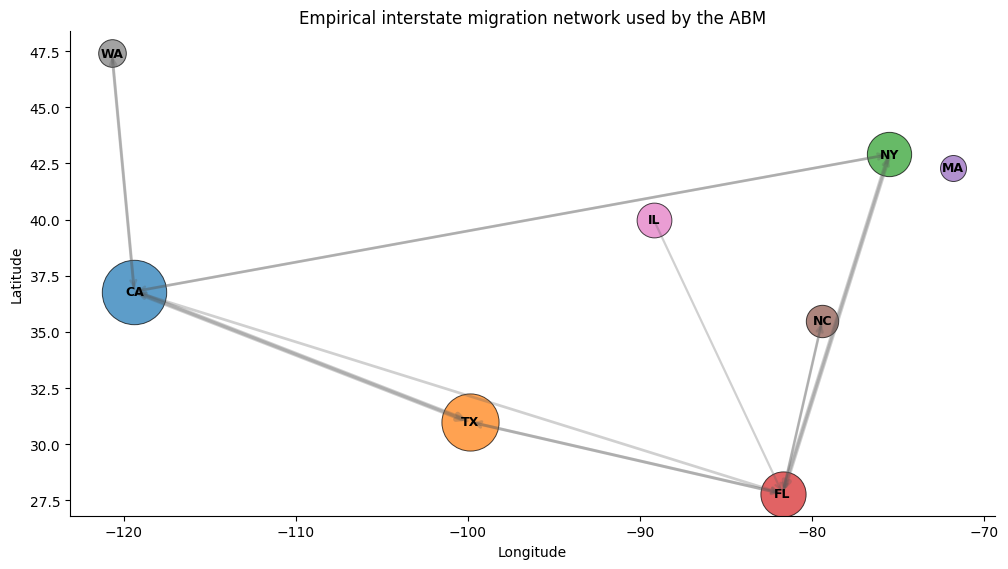

In [ ]:
# Real-world spatial presentation of the empirical migration network.
top_routes = irs_flows.nlargest(14, "returns").copy()
max_flow = top_routes["returns"].max()
pop = state_data["young_adult_population_est_18_35"]
pop_size = 350 + 1800 * (pop - pop.min()) / max(pop.max() - pop.min(), 1)

fig, ax = plt.subplots(figsize=(10.2, 5.8))
for _, row in top_routes.iterrows():
    o, d = row["origin"], row["destination"]
    y1, x1 = STATE_COORDS[o]
    y2, x2 = STATE_COORDS[d]
    lw = 0.6 + 3.0 * row["returns"] / max_flow
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=lw, alpha=0.28, color="0.35"),
    )

for state in STATE_CODES:
    lat, lon = STATE_COORDS[state]
    ax.scatter(lon, lat, s=pop_size[state], alpha=0.72, edgecolor="black", linewidth=0.7)
    ax.text(lon, lat, state, ha="center", va="center", fontsize=9, fontweight="bold")

ax.set_title("Empirical interstate migration network used by the ABM")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Exact ACS PUMS calibration of the overall interstate-move rate

The notebook now **downloads the required 2023 ACS 1-year PUMS person files automatically from the U.S. Census Bureau** when they are not already available locally.

The empirical calibration workflow is:

1. download the eight official state person ZIP files used by this model (CA, TX, NY, FL, MA, NC, IL, WA);
2. read only `AGEP`, `PWGTP`, `MIG`, `MIGSP`, and current-state `STATE/ST` in chunks;
3. keep exact ages **18–35**;
4. identify interstate movers as `MIG == 3`, with a valid previous-state FIPS code and `MIGSP != current state`;
5. weight observations using `PWGTP`;
6. write a small fixed local calibration snapshot so later runs are reproducible and do not need to redownload the microdata.

The eight-state weighted rate is the primary calibration target because the ABM itself contains those eight current-residence states. The raw PUMS ZIP files are cached locally in `pums_2023_1year/` and are not redownloaded if they already exist.

`STRICT_EMPIRICAL_CALIBRATION = True`: the final experiment will not silently replace the observed target with a guessed 5% value.

In [9]:
# Load the exact empirical mobility anchor produced from the eight official 2023 ACS 1-year PUMS person files.
RESULT_CACHE = Path("abm_outputs_research_plan_v7")
ACS_LOCAL_PATH = RESULT_CACHE / "acs_young_adult_interstate_move_rate.csv"
ACS_BY_STATE_PATH = RESULT_CACHE / "acs_young_adult_interstate_move_rate_by_state.csv"
ACS_BY_AGE_PATH = RESULT_CACHE / "acs_young_adult_interstate_move_rate_by_age.csv"
MODEL_STATE_FIPS = {"CA":6,"TX":48,"NY":36,"FL":12,"MA":25,"NC":37,"IL":17,"WA":53}
anchor = pd.read_csv(ACS_LOCAL_PATH).iloc[0]
MOVE_RATE_TARGET = float(anchor["move_rate"])
MOVE_RATE_INFO = {"rate": MOVE_RATE_TARGET, "status": anchor["source"], "scope": anchor["scope"], "empirical": True}
print("Observed ACS 18–35 interstate move-rate target:", round(MOVE_RATE_TARGET, 5))
print("Source:", MOVE_RATE_INFO["status"])
print("Scope:", MOVE_RATE_INFO["scope"])
display(pd.DataFrame([anchor]).drop(columns=["source_files"], errors="ignore").round(5))
acs_by_state = pd.read_csv(ACS_BY_STATE_PATH)
acs_by_age = pd.read_csv(ACS_BY_AGE_PATH)
display(acs_by_state.round(5), acs_by_age.round(5))


Observed ACS 18–35 interstate move-rate target: 0.03875
Source: 2023 ACS 1-year PUMS person records; exact ages 18–35; PWGTP-weighted; scope=eight modeled states
Scope: eight modeled states


,year,age_min,age_max,move_rate,weighted_population,weighted_interstate_movers,unweighted_population,unweighted_interstate_movers,scope,source
0,2023,18,35,0.03875,36550523.0,1416178.0,334763,14273,eight modeled states,2023 ACS 1-year PUMS person records; exact age...


### 3.1 External-competition scope audit (ACS PUMS)

The main ABM intentionally models eight states. To quantify the closed-system limitation rather than hide it, V7 measures what share of observed 2023 interstate in-movers to those eight states previously lived in one of the other U.S. states. This is an **empirical scope diagnostic**, not a new calibrated destination model. A full `OTHER_US` utility option would require nationwide destination-flow calibration and would change the estimand, so it is not silently inserted into the main model.


Weighted share of interstate in-movers originating outside the eight modeled states: 0.620


,state,external_origin_share
0,CA,0.584
4,MA,0.595
2,NY,0.600
7,WA,0.600
3,FL,0.626
1,TX,0.637
5,NC,0.644
6,IL,0.682


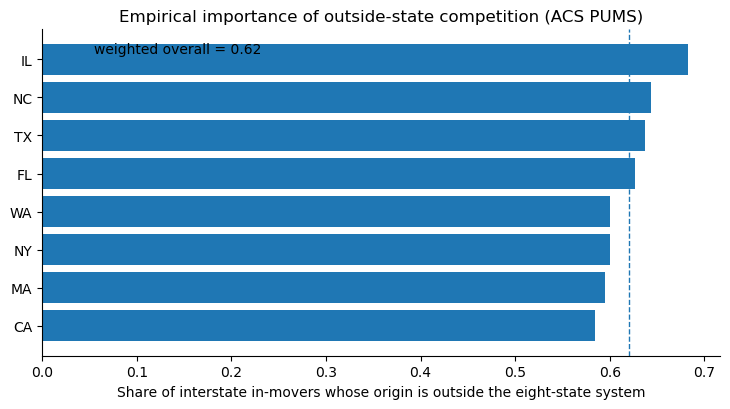

In [10]:
external_origin_by_state = pd.read_csv(RESULT_CACHE / "pums_external_origin_competition.csv")
EXTERNAL_ORIGIN_SHARE = (
    external_origin_by_state["weighted_from_other_us"].sum()
    / external_origin_by_state["weighted_interstate_inmovers"].sum()
)
print(f"Weighted share of interstate in-movers originating outside the eight modeled states: {EXTERNAL_ORIGIN_SHARE:.3f}")
display(external_origin_by_state[["state","external_origin_share"]].sort_values("external_origin_share").round(3))

fig, ax = plt.subplots(figsize=(7.4, 4.2))
g = external_origin_by_state.sort_values("external_origin_share")
ax.barh(g["state"], g["external_origin_share"])
ax.axvline(EXTERNAL_ORIGIN_SHARE, linestyle="--", linewidth=1, label=f"weighted overall = {EXTERNAL_ORIGIN_SHARE:.2f}")
ax.set_xlabel("Share of interstate in-movers whose origin is outside the eight-state system")
ax.set_title("Empirical importance of outside-state competition (ACS PUMS)")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Policy, interaction, demography, and shock parameters

In [ ]:
# Age-specific mortality pattern for the 18–35 study population.
MORTALITY_AGE = np.arange(18, 36, dtype=float)
MORTALITY_QX = np.array([
    0.000731, 0.000837, 0.000949, 0.001065, 0.001170, 0.001259,
    0.001335, 0.001406, 0.001480, 0.001560, 0.001651, 0.001749,
    0.001849, 0.001947, 0.002040, 0.002128, 0.002216, 0.002308,
])


def mortality_probability(age):
    return np.interp(
        np.asarray(age, dtype=float),
        MORTALITY_AGE,
        MORTALITY_QX,
        left=MORTALITY_QX[0],
        right=MORTALITY_QX[-1],
    )


PARAMS = {
    # IRS-calibrated destination attractiveness
    "beta_income": float(CALIBRATED_BETA[0]),
    "beta_jobs": float(CALIBRATED_BETA[1]),
    "beta_rent": float(CALIBRATED_BETA[2]),
    "beta_distance": float(CALIBRATED_BETA[3]),
    "beta_education": float(CALIBRATED_BETA[4]),
    "beta_childcare": float(CALIBRATED_BETA[5]),

    # Stay/move and social interaction
    "beta_current_state": 3.20,
    "beta_home_state": 0.20,
    "migration_cost": 1.00,
    "temperature": 0.90,
    "beta_unemployment_push": 0.45,
    "beta_job_rejection_push": 0.75,
    "beta_peer_network": 1.00,
    "beta_coorigin": 0.60,
    "beta_social_dissatisfaction": 0.90,
    "social_satisfaction_threshold": 0.35,
    "beta_crowding": 0.00,  # optional; activated only in sensitivity analysis
    "network_k": 8,
    "annual_pair_formation_rate": 0.08,

    # Direct policy pull + capacity effects
    "beta_migration_incentive": 0.55,
    "beta_housing_signal": 0.30,
    "beta_employment_signal": 0.40,
    "housing_entry_factor": 0.80,
    "housing_policy_slots": 0.05,
    "employment_policy_slots": 0.07,
    "housing_policy_effect": 0.030,
    "employment_policy_growth": 0.020,
    # Lagged rent response to excess housing demand. 0.15 is the central value;
    # Section 13 scans 0.00/0.10/0.15/0.20 as a robustness check.
    "rent_rejection_elasticity": 0.15,
    # Smooth housing-market rationing: availability becomes probabilistic as
    # remaining capacity approaches zero, avoiding a discontinuous hard wall.
    "housing_market_softness": 0.10,
    "housing_capacity_buffer": 0.05,

    # Demography
    "international_entry_rate": 0.008,
    "birth_peak_probability": 0.065,
    "birth_age_center": 29.0,
    "birth_age_spread": 5.0,
    "max_dependent_children": 3,
}

# Shock dictionaries use model-year indices. Recovery is linear after the active period.
SHOCK_SCENARIOS = {
    "baseline": {},
    "financial_crisis": {
        "start": 5, "duration": 2, "recovery_years": 3,
        "job_slot_multiplier": 0.72,
        "wage_multiplier": 0.92,
        "mortality_multiplier": 1.0,
        "migration_cost_multiplier": 1.0,
    },
    "pandemic": {
        "start": 5, "duration": 2, "recovery_years": 2,
        "job_slot_multiplier": 0.78,
        "wage_multiplier": 0.95,
        "mortality_multiplier": 2.50,
        "migration_cost_multiplier": 1.25,
    },
    "labor_shortage": {
        "start": 5, "duration": 4, "recovery_years": 2,
        "job_slot_multiplier": 1.25,
        "wage_multiplier": 1.06,
        "mortality_multiplier": 1.0,
        "migration_cost_multiplier": 1.0,
    },
}


def policy_table(
    target_state=None,
    housing=0.0,
    employment=0.0,
    migration_incentive=0.0,
    state_incentives=None,
):
    p = pd.DataFrame(0.0, index=STATE_CODES, columns=POLICY_COLS)
    if target_state is not None:
        p.loc[target_state, "housing_policy"] = float(housing)
        p.loc[target_state, "employment_incentive"] = float(employment)
        p.loc[target_state, "migration_incentive"] = float(migration_incentive)
    if state_incentives is not None:
        for state, value in state_incentives.items():
            p.loc[state, "migration_incentive"] = float(value)
    return p


# Focal state is chosen mechanically, not because it produces a preferred result.
opportunity_index = (
    state_data["job_index"]
    + state_data["housing_capacity_index"]
    - state_data["rent_index"]
)
FOCAL_STATE = (
    (opportunity_index - opportunity_index.median())
    .abs()
    .sort_values()
    .index[0]
)
print("Focal policy state:", FOCAL_STATE, STATE_NAMES[FOCAL_STATE])

Focal policy state: NY New York


## 5. Agent initialization and network-structure robustness

The default initial condition remains deliberately mixed: current state and home state are sampled independently. Two distinct robustness mechanisms are now separated:

- `network_homophily_share`: share of each agent's initial contacts preferentially drawn from the same home-state group. Default `0.0` preserves the original random-network baseline; `0.5` is tested as a structured-network alternative.
- `entrant_home_local` / `entrant_network_home_bias`: replacement-entrant assumptions retained from earlier versions and tested separately.

This distinction matters because a model should not label clustering as an emergent result if it was mechanically inserted by initialization.

In [ ]:
def logistic(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))



def initialise_agents(
    state_df,
    n_agents,
    seed,
    network_k=8,
    couple_share=0.35,
    network_homophily_share=0.0,
):
    rng = np.random.default_rng(seed)
    probs = state_df["young_adult_population_est_18_35"].to_numpy(dtype=float)
    probs /= probs.sum()

    states = rng.choice(STATE_CODES, size=n_agents, p=probs)
    home_states = rng.choice(STATE_CODES, size=n_agents, p=probs)
    age = rng.integers(18, 36, size=n_agents)

    college_prob = np.array([state_df.loc[s, "college_share_proxy"] for s in states])
    college_prob = np.where(age < 22, college_prob * 0.20, np.where(age < 25, college_prob * 0.60, college_prob))
    college = rng.binomial(1, np.clip(college_prob, 0.03, 0.75))
    skill = np.clip(rng.normal(1.0 + 0.18 * college, 0.15, n_agents), 0.55, 1.65)

    has_children = rng.binomial(1, logistic((age - 28) / 3.5 - 1))
    dependent_children = has_children * np.clip(rng.poisson(1.0, n_agents) + 1, 1, 3)

    income_anchor = np.array([0.65 * state_df.loc[s, "median_household_income"] for s in states])
    income = (
        income_anchor
        * (0.72 + 0.28 * skill)
        * (1.0 + 0.22 * college)
        * rng.lognormal(0.0, 0.12, n_agents)
    )

    agents = pd.DataFrame({
        "agent_id": np.arange(n_agents),
        "age": age,
        "college": college,
        "skill": skill,
        "income": income,
        "employed": np.ones(n_agents, dtype=int),
        "has_children": has_children,
        "dependent_children": dependent_children,
        "home_state": home_states,
        "state": states,
        "is_international": np.zeros(n_agents, dtype=int),
        "unemployed_years": np.zeros(n_agents, dtype=int),
        "job_rejected_last_year": np.zeros(n_agents, dtype=int),
        "last_move_year": np.full(n_agents, -99, dtype=int),
    })

    household_id = np.arange(n_agents, dtype=int)
    next_household = n_agents
    for state in STATE_CODES:
        eligible = np.where((states == state) & (age >= 22))[0]
        rng.shuffle(eligible)
        n_pairs = int((len(eligible) * couple_share) // 2)
        for a, b in eligible[: 2 * n_pairs].reshape(-1, 2):
            household_id[a] = next_household
            household_id[b] = next_household
            dep = max(int(agents.loc[a, "dependent_children"]), int(agents.loc[b, "dependent_children"]))
            if dep > 0:
                agents.loc[[a, b], "has_children"] = 1
                agents.loc[[a, b], "dependent_children"] = dep
            next_household += 1
    agents["household_id"] = household_id

    # Social-network initialization. The baseline remains random (share=0), while
    # the robustness experiment sets share=0.5 to introduce realistic co-origin
    # homophily without forcing all contacts to be co-origin.
    homophily = float(np.clip(network_homophily_share, 0.0, 1.0))
    network = np.empty((n_agents, network_k), dtype=int)
    all_idx = np.arange(n_agents)
    home_arr = agents["home_state"].to_numpy()

    for i in range(n_agents):
        pool = all_idx[all_idx != i]
        contacts = []
        k_home = int(round(network_k * homophily))
        if k_home > 0:
            same_home_pool = pool[home_arr[pool] == home_arr[i]]
            if len(same_home_pool):
                take = min(k_home, len(same_home_pool))
                contacts.extend(rng.choice(same_home_pool, size=take, replace=False).tolist())

        remaining = network_k - len(contacts)
        if remaining > 0:
            available = pool[~np.isin(pool, contacts)]
            contacts.extend(
                rng.choice(
                    available,
                    size=remaining,
                    replace=len(available) < remaining,
                ).tolist()
            )
        network[i] = contacts[:network_k]

    return agents, network


## 6. Interaction-driven ABM

The model combines household migration choice, social-network influence, finite housing and jobs, demographic turnover, and state-level environmental feedback. Housing is now represented as a **hybrid quantity-price constraint**: capacity can still reject excess households in the current year, but the state-specific rejection rate raises next-year rents through `rent_rejection_elasticity`. This makes excess demand partially self-correcting instead of producing only a mechanical capacity wall.

In [ ]:
class PolicySocialABM:
    """Agent-based model of 18-35 interstate migration across the eight modeled states.

    Each simulated year, agents choose a destination from state utilities (income,
    housing cost, jobs, amenities, policy incentives, distance decay) plus the
    influence of their social-network contacts. Housing and job capacity limit
    in-migration, and rejected movers feed back into next-year rents.

    Key arguments:
        interaction_strength: scales the social-influence term (1.0 = baseline).
        shocks: optional table of year-specific shocks to state attributes.
        network_homophily_share: share of contacts drawn from the agent's home state.
        record_events: keep a per-move event log (disable to save memory).
    """
    def __init__(
        self,
        state_df,
        policies,
        n_agents=EXPERIMENT_AGENTS,
        years=EXPERIMENT_YEARS,
        seed=RANDOM_SEED,
        params=None,
        interaction_strength=1.0,
        shocks=None,
        entrant_home_local=False,
        entrant_network_home_bias=False,
        network_homophily_share=0.0,
        record_events=True,
    ):
        self.base_state = state_df.copy()
        self.state = state_df.copy()
        self.policies = policies.copy()
        self.n_agents = int(n_agents)
        self.years = int(years)
        self.seed = int(seed)
        self.params = PARAMS.copy() if params is None else params.copy()
        self.interaction_strength = float(interaction_strength)
        self.shocks = {} if shocks is None else dict(shocks)
        self.entrant_home_local = bool(entrant_home_local)
        self.entrant_network_home_bias = bool(entrant_network_home_bias)
        self.network_homophily_share = float(np.clip(network_homophily_share, 0.0, 1.0))
        self.record_events = bool(record_events)

        self.params["beta_peer_network"] = PARAMS["beta_peer_network"] * self.interaction_strength
        self.params["beta_coorigin"] = PARAMS["beta_coorigin"] * self.interaction_strength
        self.params["beta_social_dissatisfaction"] = PARAMS["beta_social_dissatisfaction"] * self.interaction_strength

        self.agents, self.network = initialise_agents(
            state_df,
            n_agents=self.n_agents,
            seed=self.seed + 1000,
            network_k=self.params["network_k"],
            network_homophily_share=self.network_homophily_share,
        )
        self.network_k = self.params["network_k"]
        self.next_household_id = int(self.agents["household_id"].max() + 1)

        self.history = []
        self.move_history = []
        self.decision_rows = []
        self.mechanism_rows = []
        self.demography_rows = []
        self.snapshots = {}
        self.job_rejection_by_state = {}
        self.unfilled_jobs_by_state = {}
        self.housing_rejection_by_state = {}
        self.previous_counts = self._counts()
        self.initial_counts = self.previous_counts.copy()

        self._employment_step(-1)
        self._snapshot(BASE_YEAR)

    def _rng(self, code, t):
        return np.random.default_rng(np.random.SeedSequence([self.seed, int(code), int(t) + 100]))

    def _counts(self):
        return self.agents["state"].value_counts().reindex(STATE_CODES, fill_value=0).astype(float)

    def _state_indices(self):
        return pd.Categorical(self.agents["state"], categories=STATE_CODES).codes

    def _home_indices(self):
        return pd.Categorical(self.agents["home_state"], categories=STATE_CODES).codes

    def _shock_factors(self, t):
        if not self.shocks:
            return {
                "job_slot_multiplier": 1.0,
                "wage_multiplier": 1.0,
                "mortality_multiplier": 1.0,
                "migration_cost_multiplier": 1.0,
            }

        start = int(self.shocks.get("start", 0))
        duration = int(self.shocks.get("duration", 0))
        recovery = int(self.shocks.get("recovery_years", 0))

        if t < start:
            intensity = 0.0
        elif t < start + duration:
            intensity = 1.0
        elif recovery > 0 and t < start + duration + recovery:
            elapsed = t - (start + duration) + 1
            intensity = max(0.0, 1.0 - elapsed / (recovery + 1))
        else:
            intensity = 0.0

        def blend(key):
            target = float(self.shocks.get(key, 1.0))
            return 1.0 + intensity * (target - 1.0)

        return {
            "job_slot_multiplier": blend("job_slot_multiplier"),
            "wage_multiplier": blend("wage_multiplier"),
            "mortality_multiplier": blend("mortality_multiplier"),
            "migration_cost_multiplier": blend("migration_cost_multiplier"),
        }

    def _household_formation_step(self, t):
        a = self.agents
        rng = self._rng(15, t)
        hh = a["household_id"].to_numpy()
        sizes = a["household_id"].map(a["household_id"].value_counts()).to_numpy()
        eligible = (a["age"].to_numpy() >= 22) & (sizes == 1)
        states = a["state"].to_numpy()
        for state in STATE_CODES:
            candidates = np.where(eligible & (states == state))[0]
            if len(candidates) < 2:
                continue
            rng.shuffle(candidates)
            n_adults = int(len(candidates) * self.params["annual_pair_formation_rate"])
            n_adults -= n_adults % 2
            for i, j in candidates[:n_adults].reshape(-1, 2):
                hid = self.next_household_id
                self.next_household_id += 1
                a.loc[[i, j], "household_id"] = hid
                dep = max(int(a.loc[i, "dependent_children"]), int(a.loc[j, "dependent_children"]))
                if dep > 0:
                    a.loc[[i, j], "has_children"] = 1
                    a.loc[[i, j], "dependent_children"] = dep

    def _family_step(self, t):
        a = self.agents
        rng = self._rng(17, t)
        grouped = a.groupby("household_id", sort=False)
        hh_age = grouped["age"].mean()
        hh_children = grouped["dependent_children"].max()
        eligible = hh_age.index[
            (hh_age.to_numpy() >= 20)
            & (hh_age.to_numpy() <= 35)
            & (hh_children.to_numpy() < self.params["max_dependent_children"])
        ]
        if len(eligible) == 0:
            return 0
        ages = hh_age.loc[eligible].to_numpy()
        existing = hh_children.loc[eligible].to_numpy()
        age_profile = np.exp(-0.5 * ((ages - self.params["birth_age_center"]) / self.params["birth_age_spread"]) ** 2)
        p = np.clip(self.params["birth_peak_probability"] * age_profile * (1.0 - 0.18 * existing), 0, 0.09)
        selected = eligible[rng.random(len(eligible)) < p]
        for hid in selected:
            mask = a["household_id"] == hid
            current = int(a.loc[mask, "dependent_children"].max())
            a.loc[mask, "has_children"] = 1
            a.loc[mask, "dependent_children"] = min(current + 1, self.params["max_dependent_children"])
        return int(len(selected))


    def _rewire_agent(self, i, t):
        rng = self._rng(71 + i % 11, t + i)
        n = len(self.agents)
        all_idx = np.arange(n)
        pool = all_idx[all_idx != i]
        home = self.agents["home_state"].to_numpy()

        # Preserve the model-level homophily treatment for replacement entrants.
        # The legacy entrant_network_home_bias switch implies at least 50% same-home
        # contacts but does not overwrite a stronger explicit homophily setting.
        target_homophily = self.network_homophily_share
        if self.entrant_network_home_bias:
            target_homophily = max(target_homophily, 0.50)

        contacts = []
        k_home = int(round(self.network_k * target_homophily))
        if k_home > 0:
            same_home = pool[home[pool] == home[i]]
            if len(same_home):
                take = min(k_home, len(same_home))
                contacts.extend(rng.choice(same_home, size=take, replace=False).tolist())

        remaining = self.network_k - len(contacts)
        if remaining > 0:
            available = pool[~np.isin(pool, contacts)]
            contacts.extend(
                rng.choice(
                    available,
                    size=remaining,
                    replace=len(available) < remaining,
                ).tolist()
            )
        self.network[i] = contacts[:self.network_k]

        # Replace inbound links while approximately preserving the sender's
        # homophily treatment rather than rewiring those links completely at random.
        rows, cols = np.where(self.network == i)
        for r, c in zip(rows, cols):
            candidates = all_idx[(all_idx != r) & (all_idx != i)]
            choose_pool = candidates
            if target_homophily > 0 and rng.random() < target_homophily:
                same_home_r = candidates[home[candidates] == home[r]]
                if len(same_home_r):
                    choose_pool = same_home_r
            self.network[r, c] = int(rng.choice(choose_pool))

    def _demography_step(self, t):
        """Age agents one year; replace deaths and agents aged out of 18-35 with new entrants.

        Mortality is shock-scaled. Entrants are domestic (age 18) or international
        (Poisson-drawn count, ages around 27, placed by job/rent attractiveness).
        """
        a = self.agents
        rng = self._rng(61, t)
        factors = self._shock_factors(t)
        age = a["age"].to_numpy(dtype=int)
        mortality = np.clip(mortality_probability(age) * factors["mortality_multiplier"], 0, 0.20)
        deaths = rng.random(len(a)) < mortality
        next_age = age + 1
        age_out = (next_age > 35) & (~deaths)
        outgoing = np.where(deaths | age_out)[0]
        survivor = ~(deaths | age_out)
        a.loc[survivor, "age"] = next_age[survivor]

        intl_entries = 0
        domestic_entries = 0
        if len(outgoing):
            probs = self.base_state["young_adult_population_est_18_35"].to_numpy(dtype=float)
            probs /= probs.sum()
            shuffled = rng.permutation(outgoing)
            expected_intl = self.params["international_entry_rate"] * self.n_agents
            n_intl = min(len(outgoing), int(rng.poisson(expected_intl)))
            intl_idx = shuffled[:n_intl]
            dom_idx = shuffled[n_intl:]
            intl_entries = len(intl_idx)
            domestic_entries = len(dom_idx)

            if len(dom_idx):
                states = rng.choice(STATE_CODES, size=len(dom_idx), p=probs)
                homes = states.copy() if self.entrant_home_local else rng.choice(STATE_CODES, size=len(dom_idx), p=probs)
                a.loc[dom_idx, "age"] = 18
                a.loc[dom_idx, "state"] = states
                a.loc[dom_idx, "home_state"] = homes
                a.loc[dom_idx, "is_international"] = 0

            if len(intl_idx):
                attract = probs * self.state["job_index"].to_numpy() / np.maximum(self.state["rent_index"].to_numpy(), 0.5)
                attract /= attract.sum()
                states = rng.choice(STATE_CODES, size=len(intl_idx), p=attract)
                homes = states.copy() if self.entrant_home_local else rng.choice(STATE_CODES, size=len(intl_idx), p=probs)
                a.loc[intl_idx, "age"] = np.clip(np.rint(rng.normal(27, 4.5, len(intl_idx))), 18, 35).astype(int)
                a.loc[intl_idx, "state"] = states
                a.loc[intl_idx, "home_state"] = homes
                a.loc[intl_idx, "is_international"] = 1

            entrant_states = a.loc[outgoing, "state"].to_numpy()
            entrant_ages = a.loc[outgoing, "age"].to_numpy(dtype=int)
            college_prob = np.array([self.base_state.loc[s, "college_share_proxy"] for s in entrant_states])
            college_prob = np.where(entrant_ages < 22, college_prob * 0.20, np.where(entrant_ages < 25, college_prob * 0.60, college_prob))
            college = rng.binomial(1, np.clip(college_prob, 0.03, 0.75))
            skill = np.clip(rng.normal(1.0 + 0.18 * college, 0.15, len(outgoing)), 0.55, 1.65)
            anchor = np.array([0.65 * self.base_state.loc[s, "median_household_income"] for s in entrant_states])

            a.loc[outgoing, "college"] = college
            a.loc[outgoing, "skill"] = skill
            a.loc[outgoing, "income"] = anchor * (0.72 + 0.28 * skill) * (1 + 0.22 * college) * rng.lognormal(0, 0.12, len(outgoing))
            a.loc[outgoing, "employed"] = 0
            a.loc[outgoing, "has_children"] = 0
            a.loc[outgoing, "dependent_children"] = 0
            a.loc[outgoing, "unemployed_years"] = 0
            a.loc[outgoing, "job_rejected_last_year"] = 0
            a.loc[outgoing, "last_move_year"] = -99

            for i in outgoing:
                a.loc[i, "household_id"] = self.next_household_id
                self.next_household_id += 1
                self._rewire_agent(int(i), t)

        self.demography_rows.append({
            "year": BASE_YEAR + t + 1,
            "deaths": int(deaths.sum()),
            "age_outs": int(age_out.sum()),
            "domestic_entries": int(domestic_entries),
            "international_entries": int(intl_entries),
        })

    def _social_components(self, members, destination, state_idx, home_idx, group_counts, group_totals):
        peer = np.mean([
            np.mean(state_idx[self.network[i]] == destination)
            for i in members
        ])
        coorigin = np.mean([
            group_counts[home_idx[i], destination] / max(group_totals[home_idx[i]], 1)
            for i in members
        ])
        home = np.mean([home_idx[i] == destination for i in members])
        attachment = (
            SOCIAL_UTILITY_WEIGHTS["peer"] * peer
            + SOCIAL_UTILITY_WEIGHTS["coorigin"] * coorigin
            + SOCIAL_UTILITY_WEIGHTS["home"] * home
        ) / (
            SOCIAL_UTILITY_WEIGHTS["peer"]
            + SOCIAL_UTILITY_WEIGHTS["coorigin"]
            + SOCIAL_UTILITY_WEIGHTS["home"]
        )
        return float(peer), float(coorigin), float(home), float(attachment)

    def _base_utility_matrix(self, t):
        a = self.agents
        n = len(a)
        S = len(STATE_CODES)
        current = self._state_indices()
        home = self._home_indices()
        factors = self._shock_factors(t)

        wage = self.state["wage_index"].to_numpy() * factors["wage_multiplier"]
        jobs = self.state["job_index"].to_numpy()
        rent = self.state["rent_index"].to_numpy()
        income_anchor = 0.65 * self.base_state["median_household_income"].to_numpy() * (wage / self.base_state["wage_index"].to_numpy())
        expected_income = (
            income_anchor[None, :]
            * (0.72 + 0.28 * a["skill"].to_numpy()[:, None])
            * (1.0 + 0.22 * a["college"].to_numpy()[:, None])
        )

        U = (
            self.params["beta_income"] * np.log(np.maximum(expected_income, 1000) / np.median(income_anchor))
            + self.params["beta_jobs"] * jobs[None, :]
            - self.params["beta_rent"] * rent[None, :]
            + DESTINATION_EFFECTS.to_numpy()[None, :]
            + self.params["beta_housing_signal"] * self.policies["housing_policy"].to_numpy()[None, :]
            + self.params["beta_employment_signal"] * self.policies["employment_incentive"].to_numpy()[None, :]
            + self.params["beta_migration_incentive"] * self.policies["migration_incentive"].to_numpy()[None, :]
        )
        U -= self.params["beta_distance"] * distance_index.to_numpy()[current, :]
        U -= (
            self.params["migration_cost"]
            * factors["migration_cost_multiplier"]
            * (np.arange(S)[None, :] != current[:, None])
        )

        # Optional crowding cost relative to each state's initial representative population.
        if self.params.get("beta_crowding", 0.0) > 0:
            crowding = np.maximum(self._counts().to_numpy() / np.maximum(self.initial_counts.to_numpy(), 1) - 1.0, 0.0)
            U -= self.params["beta_crowding"] * crowding[None, :]

        U[np.arange(n), current] += (
            self.params["beta_current_state"]
            - self.params["beta_unemployment_push"] * np.minimum(a["unemployed_years"].to_numpy(), 3)
            - self.params["beta_job_rejection_push"] * a["job_rejected_last_year"].to_numpy()
        )
        U[np.arange(n), home] += self.params["beta_home_state"]
        return U, current, home

    def _migration_step(self, t):
        a = self.agents
        S = len(STATE_CODES)
        base_U, state_idx, home_idx = self._base_utility_matrix(t)
        old_states = a["state"].to_numpy().copy()
        state_idx = state_idx.copy()

        group_counts = np.zeros((S, S), dtype=int)
        np.add.at(group_counts, (home_idx, state_idx), 1)
        group_totals = group_counts.sum(axis=1)

        household_counts = a.groupby("state")["household_id"].nunique().reindex(STATE_CODES, fill_value=0).to_numpy()
        housing_slots = np.maximum(
            1,
            np.round(
                household_counts * self.base_state["vacancy_rate"].to_numpy() * self.params["housing_entry_factor"]
                + household_counts * self.policies["housing_policy"].to_numpy() * self.params["housing_policy_slots"]
            ),
        ).astype(int)
        housing_capacity = housing_slots.copy()

        households = list(a.groupby("household_id", sort=False).indices.items())
        rng = self._rng(11, t)
        order = rng.permutation(len(households))

        proposed = rejected = 0
        proposed_by_state = np.zeros(S, dtype=int)
        rejected_by_state = np.zeros(S, dtype=int)
        move_rows = []
        # Target proposal/rejection counts are household-level because housing
        # capacity is allocated to households. Accepted inflow, chain counts,
        # and mover social outcomes are person-level to match agent-year rates.
        target_proposed = target_rejected = 0
        target_accepted_agents = 0
        chain_count_agents = 0
        social_cost_sum = social_cost_n = 0
        origin_attachment_sum = 0.0

        for position in order:
            household_id, members = households[position]
            members = np.asarray(members, dtype=int)
            origin = int(state_idx[members[0]])
            hu = base_U[members].mean(axis=0)

            peer_pull = np.zeros(S)
            co_pull = np.zeros(S)
            for i in members:
                contacts = state_idx[self.network[i]]
                peer_pull += np.bincount(contacts, minlength=S) / self.network_k
                co_pull += group_counts[home_idx[i]] / max(group_totals[home_idx[i]], 1)
            hu += self.params["beta_peer_network"] * peer_pull / len(members)
            hu += self.params["beta_coorigin"] * co_pull / len(members)

            origin_peer, origin_co, origin_home, origin_attach = self._social_components(
                members, origin, state_idx, home_idx, group_counts, group_totals
            )
            dissatisfaction = max(0.0, self.params["social_satisfaction_threshold"] - origin_peer)
            hu[origin] -= self.params["beta_social_dissatisfaction"] * dissatisfaction

            z = hu / self.params["temperature"]
            z -= z.max()
            prob = np.exp(z)
            prob /= prob.sum()
            dest = int(rng.choice(S, p=prob))

            dest_peer, dest_co, dest_home, dest_attach = self._social_components(
                members, dest, state_idx, home_idx, group_counts, group_totals
            )
            social_cost = origin_attach - dest_attach
            recent_contact = False
            contact_ids = np.unique(np.concatenate([self.network[i] for i in members]))
            if len(contact_ids):
                recent_contact = bool(np.any(
                    (state_idx[contact_ids] == dest)
                    & (a.loc[contact_ids, "last_move_year"].to_numpy() >= max(0, t - 2))
                    & (a.loc[contact_ids, "last_move_year"].to_numpy() >= 0)
                ))

            is_move = dest != origin
            accepted = False
            housing_rejected = False

            if is_move:
                proposed += 1
                proposed_by_state[dest] += 1
                if STATE_CODES[dest] == FOCAL_STATE:
                    target_proposed += 1

                # Smooth housing feasibility rather than a deterministic hard wall.
                # When capacity is plentiful, acceptance is almost certain; near or
                # beyond nominal capacity, probability falls smoothly. Rejections then
                # raise next-year rent through _environment_step.
                nominal_capacity = max(float(housing_capacity[dest]), 1.0)
                remaining_ratio = float(housing_slots[dest]) / nominal_capacity
                softness = max(float(self.params.get("housing_market_softness", 0.10)), 1e-4)
                buffer = float(self.params.get("housing_capacity_buffer", 0.05))
                housing_accept_prob = float(logistic((remaining_ratio - buffer) / softness))

                if rng.random() > housing_accept_prob:
                    rejected += 1
                    rejected_by_state[dest] += 1
                    housing_rejected = True
                    if STATE_CODES[dest] == FOCAL_STATE:
                        target_rejected += 1
                else:
                    accepted = True
                    housing_slots[dest] -= 1
                    housing_slots[origin] += 1
                    if STATE_CODES[dest] == FOCAL_STATE:
                        n_people = len(members)
                        target_accepted_agents += n_people
                        chain_count_agents += int(recent_contact) * n_people
                        social_cost_sum += social_cost * n_people
                        origin_attachment_sum += origin_attach * n_people
                        social_cost_n += n_people

                    for i in members:
                        group_counts[home_idx[i], state_idx[i]] -= 1
                        group_counts[home_idx[i], dest] += 1
                        state_idx[i] = dest
                        a.loc[i, "last_move_year"] = t
                        if self.record_events:
                            move_rows.append({
                                "year": BASE_YEAR + t + 1,
                                "agent_id": int(a.loc[i, "agent_id"]),
                                "household_id": int(a.loc[i, "household_id"]),
                                "origin": STATE_CODES[origin],
                                "destination": STATE_CODES[dest],
                                "home_state": a.loc[i, "home_state"],
                                "origin_peer_share": origin_peer,
                                "origin_coorigin_share": origin_co,
                                "destination_peer_share": dest_peer,
                                "destination_coorigin_share": dest_co,
                                "origin_social_attachment": origin_attach,
                                "destination_social_attachment": dest_attach,
                                "social_cost": social_cost,
                                "chain_move": int(recent_contact),
                            })

            if self.record_events:
                self.decision_rows.append({
                    "year": BASE_YEAR + t + 1,
                    "household_id": int(household_id),
                    "origin": STATE_CODES[origin],
                    "chosen_destination": STATE_CODES[dest],
                    "proposed_move": int(is_move),
                    "accepted_move": int(is_move and accepted),
                    "housing_rejected": int(housing_rejected),
                    "origin_peer_share": origin_peer,
                    "origin_coorigin_share": origin_co,
                    "origin_social_attachment": origin_attach,
                    "destination_social_attachment": dest_attach,
                    "social_cost": social_cost,
                    "chain_move": int(recent_contact and is_move and accepted),
                })

        new_states = np.array(STATE_CODES, dtype=object)[state_idx]
        a["state"] = new_states
        if self.record_events and move_rows:
            self.move_history.append(pd.DataFrame(move_rows))

        self.housing_rejection_by_state[t] = {
            state: (rejected_by_state[j] / max(proposed_by_state[j], 1))
            for j, state in enumerate(STATE_CODES)
        }

        self.mechanism_rows.append({
            "year": BASE_YEAR + t + 1,
            "target_proposed": target_proposed,
            "target_accepted": target_accepted_agents,
            "target_housing_rejected": target_rejected,
            "target_chain_moves": chain_count_agents,
            "target_social_cost_sum": social_cost_sum,
            "target_origin_attachment_sum": origin_attachment_sum,
            "target_social_cost_n": social_cost_n,
        })

        return old_states, new_states, proposed, rejected

    def _employment_step(self, t):
        a = self.agents
        n = len(a)
        rng = self._rng(37, t)
        factors = self._shock_factors(t)
        employed = np.zeros(n, dtype=int)
        rejected_flag = np.zeros(n, dtype=int)
        states = a["state"].to_numpy()
        state_rejection = {}
        state_unfilled = {}

        for state in STATE_CODES:
            mask = states == state
            applicants = np.where(mask)[0]
            if len(applicants) == 0:
                state_rejection[state] = np.nan
                state_unfilled[state] = 0
                continue

            slot_rate = np.clip(
                0.80
                + 0.16 * (self.state.loc[state, "job_index"] - 1.0)
                + self.params["employment_policy_slots"] * self.policies.loc[state, "employment_incentive"],
                0.60,
                1.20,
            )
            slots = int(round(slot_rate * mask.sum() * factors["job_slot_multiplier"]))
            order = rng.permutation(applicants)
            remaining = slots
            for i in order:
                if remaining <= 0:
                    break
                p_match = logistic(
                    2.0
                    + 0.8 * (a.loc[i, "skill"] - 1.0)
                    + 0.30 * a.loc[i, "college"]
                    - 0.10 * min(a.loc[i, "unemployed_years"], 3)
                )
                if rng.random() < p_match:
                    employed[i] = 1
                    remaining -= 1

            rejected_here = applicants[employed[applicants] == 0]
            rejected_flag[rejected_here] = 1
            state_rejection[state] = len(rejected_here) / max(len(applicants), 1)
            state_unfilled[state] = max(remaining, 0)

        self.job_rejection_by_state[t] = state_rejection
        self.unfilled_jobs_by_state[t] = state_unfilled
        a["employed"] = employed
        a["job_rejected_last_year"] = rejected_flag
        a["unemployed_years"] = np.where(employed == 1, 0, a["unemployed_years"].to_numpy() + 1)

        wage = a["state"].map(self.state["wage_index"]).to_numpy() * factors["wage_multiplier"]
        base_wage = a["state"].map(self.base_state["wage_index"]).to_numpy()
        anchor = 0.65 * a["state"].map(self.base_state["median_household_income"]).to_numpy()
        income = (
            anchor * (wage / base_wage)
            * (0.72 + 0.28 * a["skill"].to_numpy())
            * (1.0 + 0.22 * a["college"].to_numpy())
            * np.where(employed == 1, 1.0, 0.34)
        )
        a["income"] = income * self._rng(41, t).lognormal(0, 0.04, n)

    def _environment_step(self):
        current = self._counts()
        growth = (current - self.previous_counts) / np.maximum(self.previous_counts, 1.0)

        # State-specific excess housing demand is translated into next-year rent
        # pressure. Current-year feasibility is soft/probabilistic near capacity,
        # while this lagged price channel dampens subsequent demand.
        if self.housing_rejection_by_state:
            latest_t = max(self.housing_rejection_by_state)
            rejection_rate = pd.Series(
                self.housing_rejection_by_state[latest_t],
                index=STATE_CODES,
                dtype=float,
            ).fillna(0.0)
        else:
            rejection_rate = pd.Series(0.0, index=STATE_CODES)
        rent_pressure = self.params.get("rent_rejection_elasticity", 0.0) * rejection_rate

        rent_growth = (
            0.10 * growth
            - self.params["housing_policy_effect"] * self.policies["housing_policy"]
            + 0.005 * (1.0 / self.state["housing_capacity_index"] - 1.0)
            + rent_pressure
        ).clip(-0.04, 0.12)
        self.state["rent_index"] = (self.state["rent_index"] * (1 + rent_growth)).clip(0.70, 1.80)

        skill = self.agents.groupby("state")["skill"].mean().reindex(STATE_CODES).fillna(1.0)
        job_growth = (
            0.008 * (skill - 1.0)
            + 0.008 * growth.clip(-0.15, 0.15)
            + self.params["employment_policy_growth"] * self.policies["employment_incentive"]
        ).clip(-0.04, 0.06)
        self.state["job_index"] = (self.state["job_index"] * (1 + job_growth)).clip(0.75, 1.40)
        self.previous_counts = current

    def _agent_social_utility_components(self):
        a = self.agents
        state_idx = self._state_indices()
        home_idx = self._home_indices()
        contact_state = state_idx[self.network]
        peer = (contact_state == state_idx[:, None]).mean(axis=1)

        S = len(STATE_CODES)
        counts = np.zeros((S, S), dtype=int)
        np.add.at(counts, (home_idx, state_idx), 1)
        totals = counts.sum(axis=1)
        co = np.zeros(len(a), dtype=float)
        valid = totals[home_idx] > 1
        co[valid] = (counts[home_idx[valid], state_idx[valid]] - 1) / (totals[home_idx[valid]] - 1)
        home = (state_idx == home_idx).astype(float)

        monthly = self.base_state["median_gross_rent_monthly"] * (self.state["rent_index"] / self.base_state["rent_index"])
        rent_burden = a["state"].map(monthly).to_numpy() * 12 / np.maximum(a["income"].to_numpy(), 12000)
        affordability = 1 - np.clip(rent_burden / 0.60, 0, 1)
        income_rel = a["income"].to_numpy() / max(a["income"].median(), 1)
        income_score = logistic(np.log(np.maximum(income_rel, 0.05)))

        total = (
            SOCIAL_UTILITY_WEIGHTS["peer"] * peer
            + SOCIAL_UTILITY_WEIGHTS["coorigin"] * co
            + SOCIAL_UTILITY_WEIGHTS["home"] * home
            + SOCIAL_UTILITY_WEIGHTS["employment"] * a["employed"].to_numpy()
            + SOCIAL_UTILITY_WEIGHTS["income"] * income_score
            + SOCIAL_UTILITY_WEIGHTS["affordability"] * affordability
        )
        return peer, co, home, rent_burden, total

    def _record_metrics(self, t, old_states, new_states, proposed, rejected, births):
        peer, co, home, rent_burden, social_utility = self._agent_social_utility_components()
        current_states = self.agents["state"].to_numpy()
        pop_share = self._counts() / len(self.agents)
        system = {
            "peer_colocation": float(np.mean(peer)),
            "coorigin_clustering": float(np.mean(co)),
            "population_hhi": float((pop_share ** 2).sum()),
            "move_rate": float(np.mean(old_states != new_states)),
            "housing_rejection_rate": rejected / max(proposed, 1),
            "mean_social_utility_index": float(np.mean(social_utility)),
            "mean_rent_burden_system": float(np.mean(rent_burden)),
            "births": int(births),
            "unfilled_jobs": int(sum(self.unfilled_jobs_by_state.get(t, {}).values())),
        }
        for state in STATE_CODES:
            mask = current_states == state
            g = self.agents.loc[mask]
            inflow = int(((old_states != state) & (new_states == state)).sum())
            outflow = int(((old_states == state) & (new_states != state)).sum())
            self.history.append({
                "year": BASE_YEAR + t + 1,
                "state": state,
                "population": len(g),
                "inflow": inflow,
                "outflow": outflow,
                "net_migration": inflow - outflow,
                "employment_rate": g["employed"].mean() if len(g) else np.nan,
                "mean_income": g["income"].mean() if len(g) else np.nan,
                "rent_index": self.state.loc[state, "rent_index"],
                "job_rejection_rate_state": self.job_rejection_by_state.get(t, {}).get(state, np.nan),
                "unfilled_jobs_state": self.unfilled_jobs_by_state.get(t, {}).get(state, 0),
                **system,
            })

    def _snapshot(self, year):
        self.snapshots[year] = self.agents[[
            "agent_id", "state", "home_state", "age", "employed",
            "household_id", "has_children", "is_international"
        ]].copy()

    def step(self, t):
        """Run one simulated year: demography, households, family, migration, jobs, environment, metrics."""
        self._demography_step(t)
        self._household_formation_step(t)
        births = self._family_step(t)
        old_states, new_states, proposed, rejected = self._migration_step(t)
        self._employment_step(t)
        self._environment_step()
        self._record_metrics(t, old_states, new_states, proposed, rejected, births)
        if t + 1 in {5, 10, 15, 20}:
            self._snapshot(BASE_YEAR + t + 1)

    def run(self):
        """Simulate all years; return (yearly history, move log, snapshots at years 5/10/15/20)."""
        for t in range(self.years):
            self.step(t)
        history = pd.DataFrame(self.history)
        moves = (
            pd.concat(self.move_history, ignore_index=True)
            if self.move_history
            else pd.DataFrame(columns=["year", "agent_id", "origin", "destination"])
        )
        return history, moves, self.snapshots

    def mechanism_history(self):
        return pd.DataFrame(self.mechanism_rows)

    def decision_history(self):
        return pd.DataFrame(self.decision_rows)

## 7. Calibrate the overall move level

In [ ]:
move_rate_calibration = pd.read_csv(RESULT_CACHE / "move_rate_calibration.csv")
best = move_rate_calibration.sort_values("absolute_error").iloc[0]
PARAMS["beta_current_state"] = float(best["beta_current_state"])
display(move_rate_calibration.round(5))
print("Calibrated beta_current_state:", round(PARAMS["beta_current_state"], 4))
print("Closest simulated rate:", round(float(best["simulated_move_rate"]), 5))

,beta_current_state,simulated_move_rate,target_move_rate,absolute_error
0,3.875,0.03924,0.03875,0.00049
1,3.900,0.03847,0.03875,0.00027
2,3.925,0.03861,0.03875,0.00013


Calibrated beta_current_state: 3.925
Closest simulated rate: 0.03861


## 8. Step 1 - no-policy reality baseline

The baseline uses 20 annual rounds and eight seeds. It reports mobility, clustering, housing pressure, unfilled jobs, and the **model social utility index**. The index is a model diagnostic assembled from peer co-location, co-origin concentration, home-state attachment, employment, relative income, and affordability; it should not be interpreted as a validated subjective-well-being survey score.

In [ ]:
baseline_runs = pd.read_csv(RESULT_CACHE / "baseline_runs.csv")
baseline_summary = baseline_runs.agg(["mean", "std"]).T
display(baseline_summary.loc[[
    "move_rate", "coorigin_clustering", "peer_colocation",
    "housing_rejection", "mean_social_utility_index", "unfilled_jobs"
]].round(3))
print(f"Baseline mean move rate = {baseline_runs['move_rate'].mean():.4f}; ACS calibration target = {MOVE_RATE_TARGET:.4f}.")

,mean,std
move_rate,0.041,0.002
coorigin_clustering,0.165,0.007
peer_colocation,0.170,0.010
housing_rejection,0.018,0.008
mean_social_utility_index,0.341,0.004
unfilled_jobs,0.100,0.076


Baseline mean move rate = 0.0413; ACS calibration target = 0.0387.


## 9. Step 2 — targeted policy × social-tie strength

A single focal state receives the intervention. The cross experiment separates housing policy, employment policy, and a combined package. Every active policy also contains a direct migration incentive term so the model can test how much explicit pull is needed to overcome local social attachment.

In [ ]:
INTERACTION_LEVELS = {"weak": 0.60, "medium": 1.00, "strong": 1.40}
POLICY_TYPES = ["baseline", "housing", "employment", "combined"]
STANDARD_INTENSITY = 1.0
cross_runs = pd.read_csv(RESULT_CACHE / "cross_experiment_runs.csv")
cross_summary = pd.read_csv(RESULT_CACHE / "cross_experiment_summary.csv")
display(cross_summary.round(3))

,interaction,policy,target_inflow_rate,mover_origin_attachment,social_cost,chain_share,housing_rejection,job_rejection,clustering,peer_colocation,social_utility_index
0,medium,baseline,0.005,0.136,-0.005,0.095,0.008,0.200,0.166,0.169,0.341
1,medium,combined,0.024,0.126,-0.109,0.431,0.119,0.123,0.196,0.211,0.368
2,medium,employment,0.011,0.129,-0.048,0.239,0.104,0.123,0.166,0.175,0.345
3,medium,housing,0.011,0.133,-0.046,0.208,0.008,0.200,0.165,0.173,0.345
4,strong,baseline,0.005,0.120,-0.025,0.135,0.004,0.201,0.172,0.179,0.345
5,strong,combined,0.026,0.119,-0.136,0.457,0.142,0.123,0.213,0.237,0.380
6,strong,employment,0.012,0.122,-0.061,0.240,0.113,0.126,0.170,0.183,0.348
7,strong,housing,0.011,0.120,-0.056,0.212,0.015,0.200,0.175,0.185,0.351
8,weak,baseline,0.005,0.137,0.008,0.134,0.007,0.200,0.158,0.161,0.336
9,weak,combined,0.020,0.129,-0.090,0.341,0.079,0.122,0.186,0.199,0.363


### Policy-effect interaction test

The same seed is compared with and without policy, then the policy effect under strong ties is compared with the policy effect under weak ties. This directly tests whether social interaction dampens or amplifies policy rather than inferring it from separate simulations.

In [17]:
policy_effects = pd.read_csv(RESULT_CACHE / "paired_policy_effects.csv")
interaction_modification = pd.read_csv(RESULT_CACHE / "interaction_modification.csv")
display(interaction_modification.round(4))

,policy,metric,strong_minus_weak_policy_effect,ci95_half_width
0,housing,d_target_inflow_rate,0.0008,0.0017
1,housing,d_target_social_cost,0.0124,0.0255
2,housing,d_target_chain_share,0.0175,0.1284
3,housing,d_coorigin_clustering,-0.0010,0.0109
4,employment,d_target_inflow_rate,0.0012,0.0017
5,employment,d_target_social_cost,0.0058,0.0197
6,employment,d_target_chain_share,0.0593,0.0822
7,employment,d_coorigin_clustering,-0.0043,0.0123
8,combined,d_target_inflow_rate,0.0046,0.0016
9,combined,d_target_social_cost,-0.0117,0.0207


### Power check: are the non-significant interaction effects informative?

The claim that social ties amplify only the combined package rests partly on the housing and employment strong-minus-weak effects being non-significant. That absence is only informative if the design could have detected a meaningful effect. From each effect's 95% interval (paired over the 8 cross-experiment seeds), the cell below reports the **minimum detectable effect** at 80% power and the number of seeds that would be needed for the observed effect to reach 80% power. No new simulations are needed.

In [18]:
def power_summary(effects, n_seeds, alpha=0.05, power=0.80, max_seeds=2000):
    df = n_seeds - 1
    se = effects["ci95_half_width"] / student_t.ppf(1 - alpha / 2, df)
    sd = se * np.sqrt(n_seeds)
    out = effects[["policy", "metric", "strong_minus_weak_policy_effect", "ci95_half_width"]].copy()
    out["mde_80pct_power"] = (student_t.ppf(1 - alpha / 2, df) + student_t.ppf(power, df)) * se
    def seeds_needed(effect, s):
        for n in range(3, max_seeds + 1):
            if (student_t.ppf(1 - alpha / 2, n - 1) + student_t.ppf(power, n - 1)) * s / np.sqrt(n) <= abs(effect):
                return n
        return np.nan
    out["seeds_for_observed_effect"] = [seeds_needed(e, s) for e, s in zip(out["strong_minus_weak_policy_effect"], sd)]
    return out

power_table = power_summary(policy_effects, n_seeds=len(CROSS_SEEDS))
display(power_table.round(4))
inflow = power_table[power_table["metric"] == "d_target_inflow_rate"].set_index("policy")
print(f"Target inflow: with {len(CROSS_SEEDS)} seeds the design detects strong-minus-weak effects of about "
      f"{inflow['mde_80pct_power'].median():.4f} at 80% power; the combined effect is "
      f"{inflow.loc['combined', 'strong_minus_weak_policy_effect']:.4f}, while housing and employment "
      f"({inflow.loc['housing', 'strong_minus_weak_policy_effect']:.4f}, {inflow.loc['employment', 'strong_minus_weak_policy_effect']:.4f}) "
      f"would need about {inflow.loc['housing', 'seeds_for_observed_effect']:.0f} and {inflow.loc['employment', 'seeds_for_observed_effect']:.0f} seeds.")

,policy,metric,strong_minus_weak_policy_effect,ci95_half_width,mde_80pct_power,seeds_for_observed_effect
0,housing,d_target_inflow_rate,0.0008,0.0017,0.0023,53.0
1,housing,d_target_social_cost,0.0124,0.0255,0.0352,50.0
2,housing,d_target_chain_share,0.0175,0.1284,0.1771,607.0
3,housing,d_coorigin_clustering,-0.0010,0.0109,0.0150,1337.0
4,employment,d_target_inflow_rate,0.0012,0.0017,0.0023,25.0
...,...,...,...,...,...,...
79,employment,NaN,NaN,NaN,NaN,NaN
80,combined,NaN,NaN,NaN,NaN,NaN
81,housing,NaN,NaN,NaN,NaN,NaN
82,employment,NaN,NaN,NaN,NaN,NaN


Target inflow: with 8 seeds the design detects strong-minus-weak effects of about 0.0023 at 80% power; the combined effect is 0.0046, while housing and employment (0.0008, 0.0012) would need about 53 and 25 seeds.


### Visual evidence: policy effects and interaction structure

The forest plot summarizes paired seed-level changes in target inflow relative to the no-policy baseline. The heatmap shows the corresponding mean inflow level for every policy × social-interaction cell.

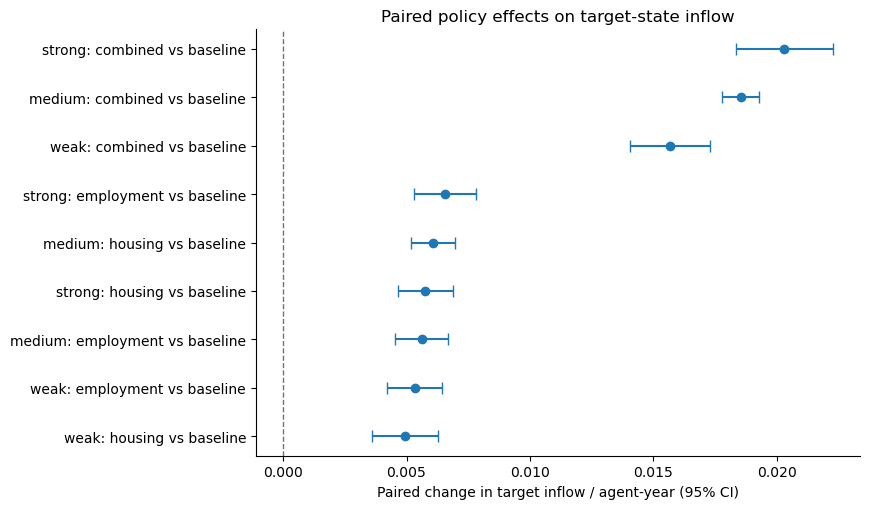

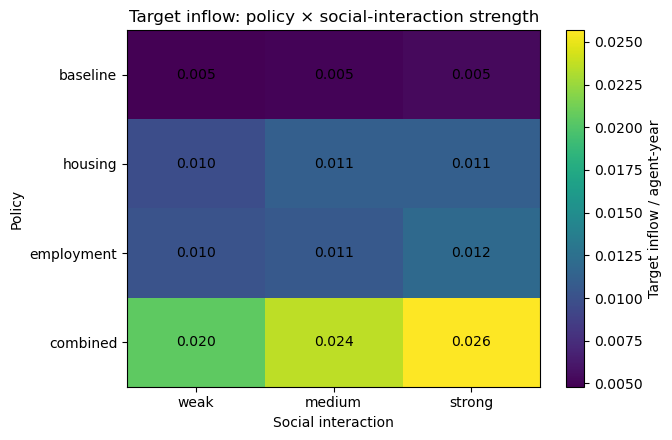

In [19]:
# 1) Forest plot of paired target-inflow effects with 95% t intervals.
forest_rows = []
for (interaction, policy), g in policy_effects.groupby(["interaction", "policy"]):
    effect, ci = mean_t_ci(g["d_target_inflow_rate"])
    forest_rows.append({
        "comparison": f"{interaction}: {policy} vs baseline",
        "effect_mean": effect,
        "effect_ci95": ci,
    })
policy_effect_forest = pd.DataFrame(forest_rows).sort_values("effect_mean")

y = np.arange(len(policy_effect_forest))
fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.errorbar(
    policy_effect_forest["effect_mean"], y,
    xerr=policy_effect_forest["effect_ci95"],
    fmt="o", capsize=4,
)
ax.axvline(0, color="0.45", linestyle="--", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(policy_effect_forest["comparison"])
ax.set_xlabel("Paired change in target inflow / agent-year (95% CI)")
ax.set_title("Paired policy effects on target-state inflow")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# 2) Policy × social-interaction heatmap.
policy_order = ["baseline", "housing", "employment", "combined"]
interaction_order = ["weak", "medium", "strong"]
pivot = (
    cross_summary.pivot(index="policy", columns="interaction", values="target_inflow_rate")
    .reindex(index=policy_order, columns=interaction_order)
)
fig, ax = plt.subplots(figsize=(6.8, 4.5))
im = ax.imshow(pivot.to_numpy(), aspect="auto")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.iloc[i, j]:.3f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Target inflow / agent-year")
ax.set_title("Target inflow: policy × social-interaction strength")
ax.set_xlabel("Social interaction")
ax.set_ylabel("Policy")
plt.tight_layout()
plt.show()

### 10.1 Tulsa Remote external-reference diagnostic

To make the policy scale interpretable without pretending that a remote-worker program is representative of all 18–35-year-olds, V7 adds a **reference-only** monetary mapping: one migration-incentive intensity unit is displayed as a `$10,000` equivalent because Tulsa Remote pays selected remote workers $10,000 to move and stay at least one year. Bartik (2025, Upjohn Institute Technical Report 25-050) estimates a 58–70% “but-for” share among Tulsa Remote member households.

The model is **not calibrated to this range**. Instead, a migration-incentive-only experiment reports the analogous simulated induced share `(policy inflow − baseline inflow) / policy inflow`. This is a diagnostic of scale and external plausibility only; population, geography, selection, and accompanying services differ substantially from Tulsa Remote.

Source: W.E. Upjohn Institute, Bartik (2025), *The Effects of Tulsa Remote on Inducing Moves to Tulsa: Estimates and Implications*, DOI 10.17848/tr25-050.


,reference_amount_usd,model_mean_induced_share,model_ci95_halfwidth,bartik_low,bartik_high,interpretation
0,10000,0.396,0.075,0.58,0.7,external reference only; not calibration


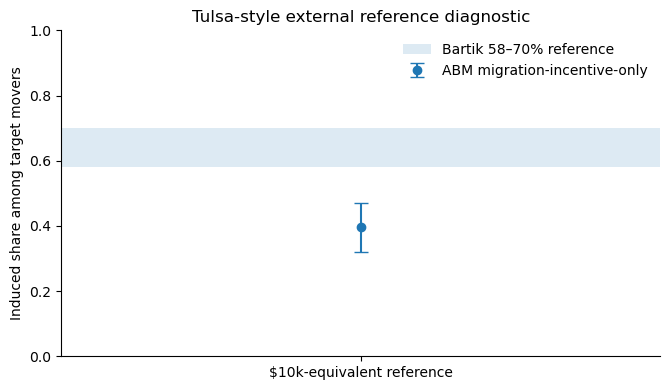

In [23]:
TULSA_DOLLAR_PER_INTENSITY = 10_000
BARTIK_BUT_FOR_LOW = 0.58
BARTIK_BUT_FOR_HIGH = 0.70
def intensity_to_dollar_equivalent(intensity, dollar_per_unit=TULSA_DOLLAR_PER_INTENSITY):
    """Reference scale only; not a fiscal or causal calibration for general young adults."""
    return np.asarray(intensity, dtype=float) * float(dollar_per_unit)

cash_reference_runs = pd.read_csv(RESULT_CACHE / "tulsa_reference_runs.csv")
tulsa_reference_summary = pd.read_csv(RESULT_CACHE / "tulsa_reference_summary.csv")
tulsa_mean = float(tulsa_reference_summary.loc[0,"model_mean_induced_share"])
tulsa_ci = float(tulsa_reference_summary.loc[0,"model_ci95_halfwidth"])
display(tulsa_reference_summary.round(3))
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.axhspan(BARTIK_BUT_FOR_LOW, BARTIK_BUT_FOR_HIGH, alpha=0.15, label="Bartik 58–70% reference")
ax.errorbar([0], [tulsa_mean], yerr=[tulsa_ci], fmt="o", capsize=5, label="ABM migration-incentive-only")
ax.set_xlim(-0.5, 0.5); ax.set_xticks([0], ["$10k-equivalent reference"])
ax.set_ylabel("Induced share among target movers")
ax.set_title("Tulsa-style external reference diagnostic")
ax.set_ylim(0, 1); ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 10.2 Saturation-curve fit: estimating the response ceiling

A finite grid cannot show where the response actually levels off. To estimate *where* the response levels off, a Hill saturation curve is fitted to the combined-package sweep, separately for each social-tie strength:

$$y(x) = y_0 + A\,\frac{x^n}{K^n + x^n}$$

`y0` is the no-policy inflow (the baseline is not zero, so it is kept as a free intercept), `y0 + A` is the fitted **response ceiling**, `K` is the half-response intensity, and `n` controls curvature. Uncertainty comes from a seed-level bootstrap on `sweep_runs`.

Reading the result: if the observed response at 4.0 is already ≥95% of the fitted ceiling, the grid has effectively reached the plateau. If not, or if `K` sits beyond the grid (the ceiling is then an extrapolation), the notebook flags that the sweep should be extended rather than treating the fitted ceiling as reliable.

,interaction,baseline_y0,fitted_ceiling,ceiling_ci_low,ceiling_ci_high,half_response_K,K_ci_low,K_ci_high,hill_n,intensity_90pct_gain,intensity_95pct_gain,share_of_gain_at_6,n_bootstrap_fits,verdict
0,weak,0.0069,0.1115,0.1101,0.1133,1.9981,1.9434,2.0550,3.0039,4.1522,5.3248,0.9532,300,plateau reached within grid
1,medium,0.0081,0.1094,0.1083,0.1106,1.8722,1.8017,1.9259,3.2599,3.6735,4.6198,0.9739,300,plateau reached within grid
2,strong,0.0085,0.1099,0.1085,0.1110,1.7731,1.7196,1.8198,3.0859,3.6138,4.6039,0.9663,300,plateau reached within grid


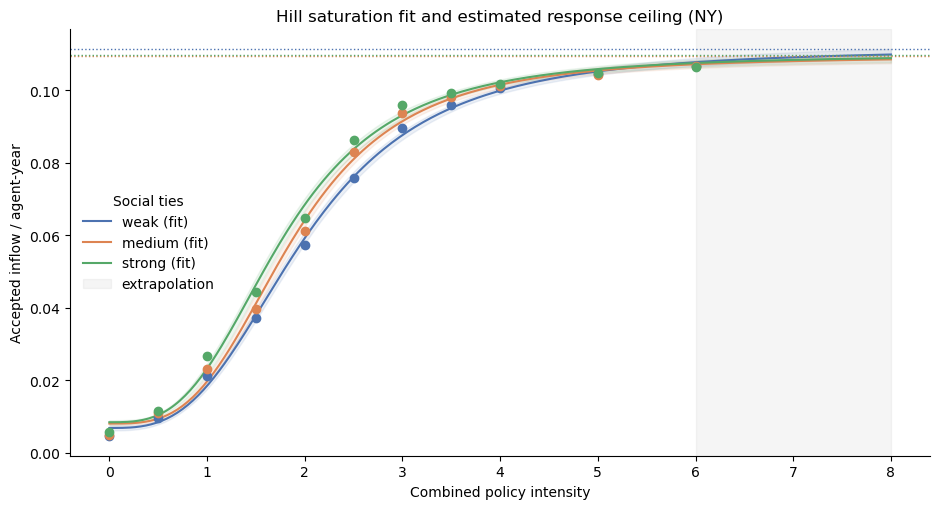

In [24]:
from scipy.optimize import curve_fit

def hill_with_baseline(x, y0, A, K, n):
    x = np.asarray(x, dtype=float)
    return y0 + A * x**n / (K**n + x**n)

def fit_hill(x, y):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    y0_guess = float(y[np.argmin(x)])
    A_guess = max(float(y.max() - y0_guess), 1e-6)
    p0 = [y0_guess, A_guess, float(np.median(x[x > 0])), 2.0]
    bounds = ([-np.inf, 0.0, 1e-3, 0.3], [np.inf, 10 * max(abs(A_guess), 1e-3) + 1.0, 50.0, 8.0])
    popt, _ = curve_fit(hill_with_baseline, x, y, p0=p0, bounds=bounds, maxfev=20000)
    return popt

def _seed_col(df):
    for c in ["seed", "run_seed", "replicate", "rep"]:
        if c in df.columns:
            return c
    return None

HILL_BOOTSTRAP = 300
SWEEP_X_MAX = float(sweep_summary["policy_intensity"].max())
hill_rows, hill_boot = [], {}
rng_hill = np.random.default_rng(RANDOM_SEED)
seed_col = _seed_col(sweep_runs)

for label in ["weak", "medium", "strong"]:
    g = sweep_summary[sweep_summary["interaction"] == label].sort_values("policy_intensity")
    y0, A, K, n = fit_hill(g["policy_intensity"], g["target_inflow_rate"])
    ceiling = y0 + A
    observed_at_max = float(g["target_inflow_rate"].iloc[-1])
    gain_at_max = observed_at_max - y0
    # Bootstrap over seeds: resample seeds, rebuild the mean curve, refit.
    boot = []
    runs = sweep_runs[sweep_runs["interaction"] == label]
    if seed_col is not None and runs[seed_col].nunique() > 1:
        seeds = runs[seed_col].unique()
        for _ in range(HILL_BOOTSTRAP):
            pick = rng_hill.choice(seeds, size=len(seeds), replace=True)
            sample = pd.concat([runs[runs[seed_col] == s] for s in pick])
            curve = sample.groupby("policy_intensity")["target_inflow_rate"].mean()
            try:
                b = fit_hill(curve.index.to_numpy(), curve.to_numpy())
                boot.append(b)
            except RuntimeError:
                continue
    boot = np.array(boot)
    hill_boot[label] = boot
    ceiling_lo = ceiling_hi = K_lo = K_hi = np.nan
    if len(boot):
        ceiling_lo, ceiling_hi = np.percentile(boot[:, 0] + boot[:, 1], [2.5, 97.5])
        K_lo, K_hi = np.percentile(boot[:, 2], [2.5, 97.5])
    # Intensity at which the fitted curve reaches 90% / 95% of its gain A.
    x90 = K * (0.90 / 0.10) ** (1.0 / n)
    x95 = K * (0.95 / 0.05) ** (1.0 / n)
    share_reached = gain_at_max / A if A > 0 else np.nan
    if K > SWEEP_X_MAX:
        verdict = "ceiling extrapolated (K beyond grid) - extend sweep"
    elif share_reached >= 0.95:
        verdict = "plateau reached within grid"
    else:
        verdict = "still rising - extend sweep"
    hill_rows.append({
        "interaction": label, "baseline_y0": y0, "fitted_ceiling": ceiling,
        "ceiling_ci_low": ceiling_lo, "ceiling_ci_high": ceiling_hi,
        "half_response_K": K, "K_ci_low": K_lo, "K_ci_high": K_hi, "hill_n": n,
        "intensity_90pct_gain": x90, "intensity_95pct_gain": x95,
        f"share_of_gain_at_{SWEEP_X_MAX:g}": share_reached,
        "n_bootstrap_fits": len(boot), "verdict": verdict,
    })

hill_summary = pd.DataFrame(hill_rows)
display(hill_summary.round(4))

fig, ax = plt.subplots(figsize=(9.5, 5.2))
x_ext = np.linspace(0, max(8.0, SWEEP_X_MAX), 300)
for label in ["weak", "medium", "strong"]:
    g = sweep_summary[sweep_summary["interaction"] == label].sort_values("policy_intensity")
    row = hill_summary.set_index("interaction").loc[label]
    params = row[["baseline_y0", "fitted_ceiling", "half_response_K", "hill_n"]].to_numpy(dtype=float)
    params[1] = params[1] - params[0]  # ceiling -> A
    color = INTERACTION_COLORS[label]
    ax.scatter(g["policy_intensity"], g["target_inflow_rate"], color=color, zorder=3)
    ax.plot(x_ext, hill_with_baseline(x_ext, *params), color=color, label=f"{label} (fit)")
    ax.axhline(row["fitted_ceiling"], color=color, linestyle=":", linewidth=1)
    boot = hill_boot[label]
    if len(boot):
        band = np.array([hill_with_baseline(x_ext, *b) for b in boot])
        lo, hi = np.percentile(band, [2.5, 97.5], axis=0)
        ax.fill_between(x_ext, lo, hi, color=color, alpha=0.10)
ax.axvspan(SWEEP_X_MAX, x_ext.max(), color="grey", alpha=0.08, label="extrapolation")
ax.set_xlabel("Combined policy intensity")
ax.set_ylabel("Accepted inflow / agent-year")
ax.set_title(f"Hill saturation fit and estimated response ceiling ({FOCAL_STATE})")
ax.legend(title="Social ties", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 11. Step 3 — extreme shocks

The migration system is exposed to exogenous shocks that change job slots, wages, mortality, or migration cost at specified years and then allow gradual recovery. The substantive case is the **labour shortage**: unfilled job slots rise from 0.19 in the no-shock baseline to 21.5, while the move rate barely changes (0.041 → 0.038). Migration within the eight-state system does not fill a structural labour shortage.

*Footnote.* Financial-crisis and pandemic-like shocks were also tested. Both moved the system move rate by less than one percentage point (0.046 and 0.040 vs 0.041 at baseline; the financial-crisis change is about 12% in relative terms, and no seed-level interval is reported) and left clustering, housing rejection and the social utility index essentially unchanged. They remain in the summary table but are not interpreted further.

In [29]:
SHOCK_NAMES = ["baseline", "financial_crisis", "pandemic", "labor_shortage"]
shock_runs = pd.read_csv(RESULT_CACHE / "shock_runs.csv")
shock_summary = pd.read_csv(RESULT_CACHE / "shock_summary.csv")
display(shock_summary.round(3))

,shock,move_rate,clustering,housing_rejection,social_utility_index,unfilled_jobs
0,baseline,0.041,0.160,0.036,0.338,0.189
1,financial_crisis,0.046,0.162,0.039,0.338,0.233
2,labor_shortage,0.038,0.162,0.034,0.340,21.511
3,pandemic,0.040,0.162,0.040,0.338,0.278


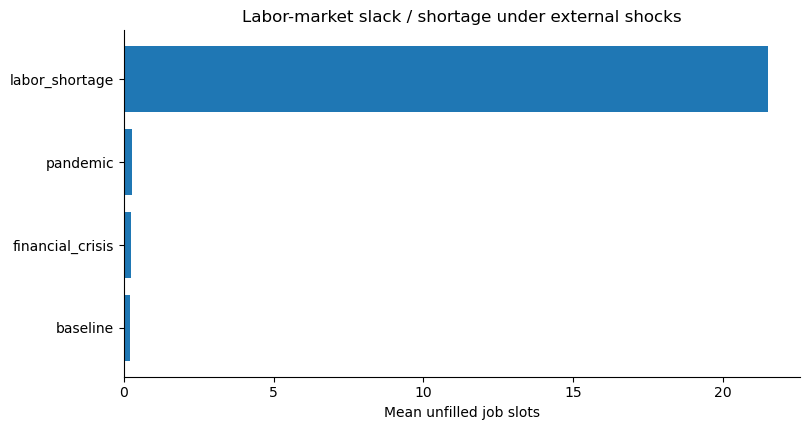

In [30]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))
g = shock_summary.sort_values("unfilled_jobs")
ax.barh(g["shock"], g["unfilled_jobs"])
ax.set_xlabel("Mean unfilled job slots")
ax.set_title("Labor-market slack / shortage under external shocks")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 12. Static interstate competition (footnote)

A stylised static scenario gave every state a different direct migration incentive, generated mechanically from each state's relative housing capacity and job conditions. It produced no substantive finding and is kept only as a footnote:

- Final-year net migration stays within ±2.5 agents per state (in a system of about 600 agents) and no seed-level interval is available.
- The ranking largely restates the incentive rule: the gainers (FL, NC) are the states with the highest housing capacity, and net migration tracks the housing-capacity index (Spearman ρ = +0.78, n = 8), which is itself an input to the incentives.
- Mean employment (0.80) and unfilled jobs (0) are identical across states, so the scenario adds no labour-market contrast.

A dynamic government-response game remains an extension.

In [31]:
competition_summary = pd.read_csv(RESULT_CACHE / "state_competition_summary.csv")
# Employment and unfilled jobs are identical across states in this scenario, so only net migration is shown.
display(competition_summary[["state", "mean_net_migration"]].sort_values("mean_net_migration").round(2))

,state,mean_net_migration
2,IL,-1.33
0,CA,-1.17
5,NY,-1.00
6,TX,-1.00
7,WA,-0.50
3,MA,0.50
4,NC,2.00
1,FL,2.50
